# Part 19: More Hypothesis Testing {-}

## The Multiple Testing Problem {-}

Possibly the biggest drawback of the hypothesis testing framework is the
**multiple testing problem**. 

**Exercise:** Suppose
a sequence of 100 independent hypothesis tests are conducted, in every case
the null hypothesis is true, and $\alpha = 0.05$ is used. How many of 
these tests will reject the null?

\answerlines{5}

**Exercise:** Suppose that $m$ independent hypothesis tests are conducted,
in every case the null hypothesis is true. What is the probability of at least
one rejection, if the same $\alpha$ is used for all tests?

\answerlines{5}

\newpage

In recognition of the multiple testing problem, recent advances have been
made in controlling the **false discovery rate (FDR)**, instead
of worrying about making one or more Type I error.

The false discovery rate can be defined as follows:
\begin{equation*}
   \mbox{FDR} = \frac{\mbox{number of false positives}}{\mbox{number of rejections}}.
\end{equation*}
Hence, FDR is the proportion of the rejected null hypotheses which are
"false discoveries."

_We should be clear:_ This approach is "solving" the multiple testing problem
by, more or less, changing the objective. Still, FDR seems like a very reasonable
alternative to control instead of limiting the probability of a Type I error.

\newpage

Benjamini and Hochberg (_JRSSB_, Vol. 57) presented a simple procedure which limits the
expected value of the FDR below a chosen $\alpha$ level:

1. Sort the p-values from smallest to largest, denote these $p_{(1)}, p_{(2)}, \ldots, p_{(m)}$.

2. Find the largest $k$ such that $p_{(k)} \leq k \alpha /m$

3. The hypotheses with p-values less than or equal to $p_{(k)}$ can be claimed as "discoveries" for this choice of $\alpha$.

It should be stressed that the validity of this procedure assumes that the
individual hypothesis tests are **independent** or satisfy certain dependency
conditions. Extensions do exist; for example, the 
**Benjamini-Hochberg-Yekutielli procedure** divides
the factor $k\alpha/m$ by $\sum_{i=1}^m 1/i$ and works under a wider range of
dependence situations.

\newpage

The function `multipletests()` from `statsmodels`, when used with argument `method="fdr_bh"` will
adjust the supplied p-values, returning the smallest choice of $\alpha$ such
that a discovery would be claimed for each test. The choice `method="fdr_by"` implements the Benjamini-Hochberg-Yekutielli procedure.

The syntax is illustrated below. Note that the first two components returned from the function are (1) a boolean vector (indicating whether or not that p-value is small enough to claim a discovery) and (2) an "adjusted" p-value that can be intepreted as the smallest choice of $\alpha$ for which this test corresponds to a discovery.

In [1]:
from statsmodels.stats.multitest\
   import multipletests
from scipy.stats import uniform
import numpy as np

simpvals = uniform.rvs(size=1000)

discovery, adjpval = multipletests(simpvals, 
    alpha = 0.05, method="fdr_bh")[0:2]

\newpage

**Exercise:** Consider the output below and comment.

\answerlines{8}

In [2]:
print(np.mean(simpvals < 0.05))
print(np.mean(simpvals < 0.5))

print(np.mean(adjpval < 0.05))
print(np.mean(adjpval < 0.5))

0.06
0.488
0.0
0.011


\newpage

**Example: Simple Pairs Trading**

A **time series** is a sequence of random variables
(or, the actual observed values of those random variables) that
model a sequence of data over time. Typically these observations
are assumed to be equally spaced in time. Denote this $X_1, X_2,\ldots$
or $\{X_t\}$.

A time series is said to be **stationary** if the 
**uncondtional** mean and variance is constant ($E(X_i) = \mu$
and $V(X_i) = \sigma^2$) and the covariance structure also does not
change with time, i.e., ${\rm Cov}(X_{t}, X_{t+h})$ only depends on
$h$, and not on $t$, for any choice of $h$ and $t$. Stationarity
is a crucial concept for time series models.

Stationary time series exhibit **mean reversion**:
The series may move away from $\mu$ for periods of time, but it will inevitably
drift back to $\mu$. The example below shows a series simulated from the
AR(1) model, with $\mu=0$.

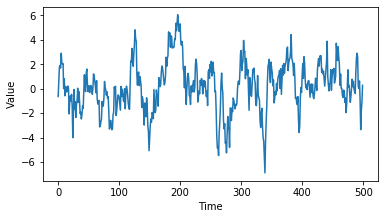

In [3]:
from statsmodels.tsa.arima_process import arma_generate_sample
import matplotlib.pyplot as plt

ar = np.r_[1, -0.9]
ma = np.r_[1]
sims = arma_generate_sample(ar=ar, ma=ma,nsample=500)

plt.figure(figsize=[6,3.2])
plt.plot(sims)
plt.xlabel("Time")
plt.ylabel("Value")
plt.show()

**Exercise:** Can time series of stock prices be modelled using
stationary time series models?

\answerlines{8}

A pair of time series $\{X_t\}$ and $\{Y_t\}$ are said to be
**cointegrated** if there exists a constant $\lambda$
such that $X_t - \lambda Y_t$ is stationary. Note that this does
not require that either $\{X_t\}$ or $\{Y_t\}$ be stationary.

This sets up a simple \textcolor{red}{pairs trading} strategy: **If**
one can finds pairs of stocks whose prices are cointegrated, then
we can use mean reversion of $X_t - \lambda Y_t$ to execute trades
that will reliably make money.

Hypothesis tests do exist that test for cointegration. Here, we
will utilize the **Phillips-Ouliaris Test** for assessing
co-integration.

\newpage

**Exercise:** What is the null hypothesis with this cointegration test?
Does that seem to be the reasonable choice?

\answerlines{6}

**Exercise:**
One could search over many pairs of stocks in an attempt to
find cointegrated pairs. What are potential problems with this approach?

\answerlines{8}

\newpage

I constructed a data set consisting of 1000 NYSE closing price time series, covering the period January through August 2020.

In [4]:
import pandas as pd
import numpy as np

stocksample = pd.read_csv("stocksample2.csv")

stockdat = stocksample.iloc[:,1:]
symbs = stocksample['Symbol']
numsymbs = len(symbs)
numtests = int(numsymbs/2)

Next randomly pair up the symbols:

In [5]:
np.random.seed(0)

sp = np.array(np.random.choice(range(numsymbs),
      size=[int(numtests),2],replace=False))


\newpage

Now calculate the p-values for each of the tests:

In [6]:
from arch.unitroot.cointegration \
   import phillips_ouliaris

pval = np.zeros(numtests)

for i in range(numtests):
    potest = phillips_ouliaris(
        stockdat.iloc[sp[i][0],:], 
        stockdat.iloc[sp[i][1],:],trend="n")
    pval[i] = potest._pvalue

How many of the p-values are less than 0.05?

In [7]:
sum(pval < 0.05)

58

\newpage

What happens when we try to control the false discovery rate?

In [8]:
discovery, adjpval = multipletests(pval, 
    alpha = 0.05, method='fdr_by')[0:2]

sum(discovery)

5

This is a good example of why one needs to be careful of
the multiple testing problem. If you search over enough pairs,
some are going to appear to be cointegrated. False positives are
inevitable.

\newpage

## The Likelihood Ratio Test {-}

To this point we have considered cases where the choice of the test statistic was either (1) based on "intuition," i.e. an understanding of what statistic would be relevant in assessing a particular hypothesis; or (2)
provided to us, e.g., in the Phillips-Ouliaris Test.

There is a general framework, based on maximum likelihood, for constructing test statistics that are optimal in the sense that they control the probability of Type II error as much as possible for fixed choice of $\alpha$. Crucially, the test statistic that results has a simple (approximate) distribution under the null hypothesis; we have already seen how important this is to performing a test.

The test is referred to as the **likelihood ratio test** because it constructs a test statistic for testing $H_0: \theta \in \Theta_0$ versus $H_1: \theta \notin \Theta_0$ via the ratio
\begin{equation*}
   T = -2 \log \left(\frac{\max_{\theta \in \Theta_0} L(\theta)}{\max_{\theta \notin \Theta_0} L(\theta)}\right)
\end{equation*}

**Exercise:** Explain why this is a reasonable choice of test statistic for performing this test. For what values of $T$ should this test reject?

\answerlines{6}

\newpage

**Important Result:** Under "regularity conditions" and the assumption that $P(T=0)=0$, then $T$ has (asymptotically) the chi-squared distribution with degrees of freedom equal to
\begin{equation*}
\mbox{Number of free parameters under $H_1$} - \mbox{Number of free parameters under $H_0$}
\end{equation*}

Hence, for fixed choice of the level `alkpha`, one would reject $H_0$ if $T$ is larger than `chi2.ppf(1-alpha, df)`. Alternatively, the p-value can be calculated as `1-chi2.cdf(T, df)`.

**Exercise:** Is the assumption that $P(T=0)=0$ restrictive in practice?

\answerlines{8}

\newpage

**Exercise:** Suppose that $X_1, X_2, \ldots, X_n$ are i.i.d. Normal$(\mu_1,\sigma^2)$ and $Y_1, Y_2, \ldots, Y_n$ are i.i.d. Normal$(\mu_2, \sigma^2)$. Assume further that the $X$ and $Y$ are independent and that $\sigma^2$ is known. Test $H_0: \mu_1 = \mu_2$ versus $H_1: \mu_1 \neq \mu_2$.

\answerlines{67}

\newpage

**Exercise:** Develop a test for constant volatility.

\answerlines{45}